# Análise das características, fase 3

A base de dados extraída é composta por **13** características e **924** entradas.


In [1]:
%%html
<link rel="stylesheet" href="./style.css">

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.preprocessing import StandardScaler

from data import df3, df3_categorical_features, df3_numerical_features

In [3]:
scaler = StandardScaler()

scaled_df3 = df3.copy()
scaled_df3[df3_numerical_features] = scaler.fit_transform(df3[df3_numerical_features])

## Correlações numéricas


In [4]:
def _compute_correlation_matrix(
    data_frame,
    columns,
    method,
):
    """Compute a correlation matrix."""
    return data_frame[columns].corr(method=method)


def _get_strong_correlation_pairs(
    correlation_matrix,
    threshold,
):
    """Extract unique feature pairs above an absolute correlation threshold."""
    upper_triangle = correlation_matrix.where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1,
        ).astype(bool)
    )

    pairs = upper_triangle.stack().reset_index()

    pairs.columns = [
        "feature_1",
        "feature_2",
        "correlation",
    ]

    pairs["abs_correlation"] = pairs["correlation"].abs()

    return (
        pairs[pairs["abs_correlation"] >= threshold]
        .sort_values(
            "abs_correlation",
            ascending=False,
        )
        .reset_index(drop=True)
    )


def _build_correlation_pairs_table(
    spearman_matrix,
    pearson_matrix,
    threshold,
):
    """Build the strong-correlation summary table."""
    pairs = _get_strong_correlation_pairs(
        spearman_matrix,
        threshold,
    )

    results = []

    for _, pair in pairs.iterrows():
        feature_1 = pair["feature_1"]
        feature_2 = pair["feature_2"]

        results.append(
            {
                "Feature 1": feature_1,
                "Feature 2": feature_2,
                "Spearman": spearman_matrix.loc[
                    feature_1,
                    feature_2,
                ],
                "Pearson": pearson_matrix.loc[
                    feature_1,
                    feature_2,
                ],
            }
        )

    return pd.DataFrame(results)


def _plot_correlation_matrix(
    correlation_matrix,
    title,
    figsize,
):
    """Plot a correlation heatmap."""
    plt.figure(figsize=figsize)

    sns.heatmap(
        correlation_matrix,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        annot=True,  # mostra os valores
        fmt=".2f",  # duas casas decimais
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()


def _display_correlation_pairs_table(
    pairs,
    title,
    threshold,
):
    """Display strong correlation pairs as an HTML table."""
    if pairs.empty:
        table = pd.DataFrame(
            {"Result": [f"No pairs with |Spearman| ≥ {threshold:.2f}."]}
        )
    else:
        table = pairs.copy()

        for column in ["Spearman", "Pearson"]:
            table[column] = table[column].map(
                lambda value: f"{value:.3f}" if pd.notna(value) else "—"
            )

    display(table.style.hide(axis="index").set_caption(title))


def _analyze_correlation_population(
    data_frame,
    columns,
    *,
    threshold,
    figsize,
):
    """Run one correlation analysis."""
    spearman = _compute_correlation_matrix(
        data_frame,
        columns,
        method="spearman",
    )

    pearson = _compute_correlation_matrix(
        data_frame,
        columns,
        method="pearson",
    )

    strong_pairs = _build_correlation_pairs_table(
        spearman,
        pearson,
        threshold,
    )

    _plot_correlation_matrix(
        spearman,
        "Spearman Correlation",
        figsize,
    )

    _plot_correlation_matrix(
        pearson,
        "Pearson Correlation",
        figsize,
    )

    _display_correlation_pairs_table(
        strong_pairs,
        (f"Strong Numerical Correlations (|Spearman| ≥ {threshold:.2f})"),
        threshold,
    )

    return {
        "spearman": spearman,
        "pearson": pearson,
        "strong_pairs": strong_pairs,
    }


def display_numerical_correlation_analysis(
    data_frame,
    threshold=0.7,
    figsize=(12, 10),
):
    """
    Analyze numerical feature correlations.
    """
    columns = df3_numerical_features

    if not columns:
        raise ValueError("No numerical condition-count features were found.")

    return _analyze_correlation_population(
        data_frame,
        columns,
        threshold=threshold,
        figsize=figsize,
    )


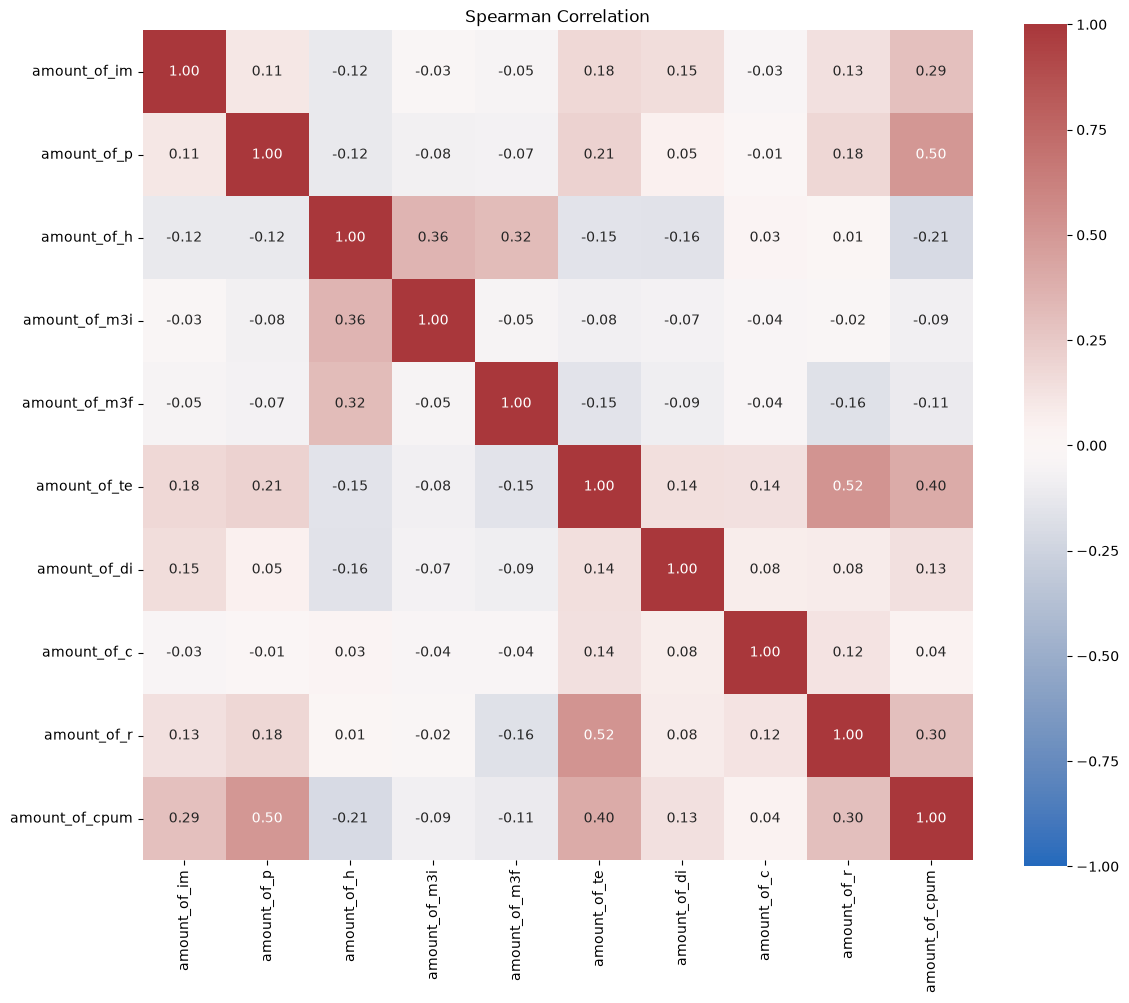

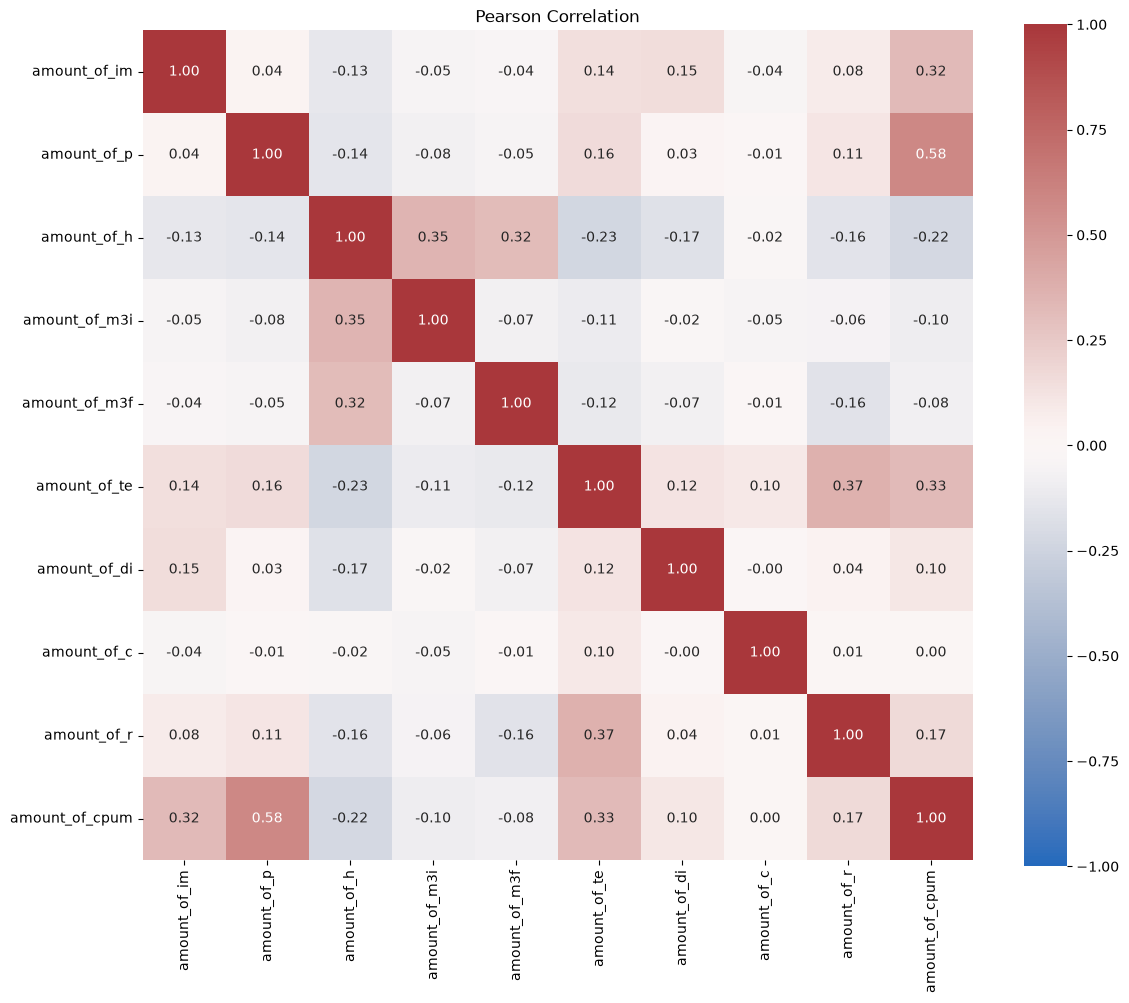

Feature 1,Feature 2,Spearman,Pearson
amount_of_te,amount_of_r,0.521,0.372
amount_of_p,amount_of_cpum,0.503,0.579


In [5]:
correlation_results = display_numerical_correlation_analysis(
    scaled_df3,
    threshold=0.5,
)

## Correlações categóricas


In [6]:
def _compute_contingency_table(
    data_frame,
    feature_1,
    feature_2,
):
    """Compute a contingency table for two categorical features."""
    return pd.crosstab(
        data_frame[feature_1],
        data_frame[feature_2],
        dropna=False,
    )


def _compute_cramers_v(
    data_frame,
    feature_1,
    feature_2,
):
    """Compute Cramér's V for two categorical features."""
    contingency_table = _compute_contingency_table(
        data_frame,
        feature_1,
        feature_2,
    )

    observed = contingency_table.to_numpy()

    chi2, _, _, _ = stats.chi2_contingency(observed)

    n = observed.sum()
    rows, columns = observed.shape

    phi2 = chi2 / n

    # Bias-corrected Cramér's V
    phi2_corrected = max(
        0,
        phi2 - ((columns - 1) * (rows - 1)) / (n - 1),
    )

    rows_corrected = rows - (((rows - 1) ** 2) / (n - 1))

    columns_corrected = columns - (((columns - 1) ** 2) / (n - 1))

    denominator = min(
        columns_corrected - 1,
        rows_corrected - 1,
    )

    if denominator <= 0:
        return 0.0

    return np.sqrt(phi2_corrected / denominator)


def _build_categorical_association_table(
    data_frame,
    columns,
):
    """Build the categorical association summary table."""
    results = []

    for index, feature_1 in enumerate(columns):
        for feature_2 in columns[index + 1 :]:
            contingency_table = _compute_contingency_table(
                data_frame,
                feature_1,
                feature_2,
            )

            chi2, p_value, _, _ = stats.chi2_contingency(contingency_table)

            results.append(
                {
                    "Feature 1": feature_1,
                    "Feature 2": feature_2,
                    "Cramér's V": _compute_cramers_v(
                        data_frame,
                        feature_1,
                        feature_2,
                    ),
                    "Chi-square": chi2,
                    "p-value": p_value,
                    "N": contingency_table.to_numpy().sum(),
                }
            )

    return (
        pd.DataFrame(results)
        .sort_values(
            "Chi-square",
            ascending=False,
        )
        .reset_index(drop=True)
    )


def _plot_categorical_association(
    data_frame,
    feature_1,
    feature_2,
    figsize,
):
    """Plot the distribution of one categorical feature by another."""
    proportions = pd.crosstab(
        data_frame[feature_1],
        data_frame[feature_2],
        normalize="index",
    )

    ax = proportions.plot(
        kind="bar",
        stacked=True,
        figsize=figsize,
    )

    ax.set_xlabel(feature_1)
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1)

    ax.set_title(f"{feature_2} Distribution by {feature_1}")

    ax.legend(
        title=feature_2,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    plt.tight_layout()
    plt.show()


def _display_categorical_association_table(
    associations,
    title,
):
    """Display categorical association results as an HTML table."""
    table = associations.copy()

    for column in ["Cramér's V", "Chi-square", "p-value"]:
        table[column] = table[column].map(
            lambda value: f"{value:.3f}" if pd.notna(value) else "—"
        )

    display(table.style.hide(axis="index").set_caption(title))


def display_categorical_correlation_analysis(
    data_frame,
    figsize=(8, 6),
):
    """
    Analyze associations between categorical predictor features.
    """
    columns = df3_categorical_features

    if len(columns) < 2:
        raise ValueError("At least two categorical features are required.")

    associations = _build_categorical_association_table(
        data_frame,
        columns,
    )

    for index, row in associations.iterrows():
        _plot_categorical_association(
            data_frame,
            row["Feature 1"],
            row["Feature 2"],
            figsize,
        )

    _display_categorical_association_table(
        associations,
        "Categorical Feature Associations",
    )

    return {
        "associations": associations,
    }

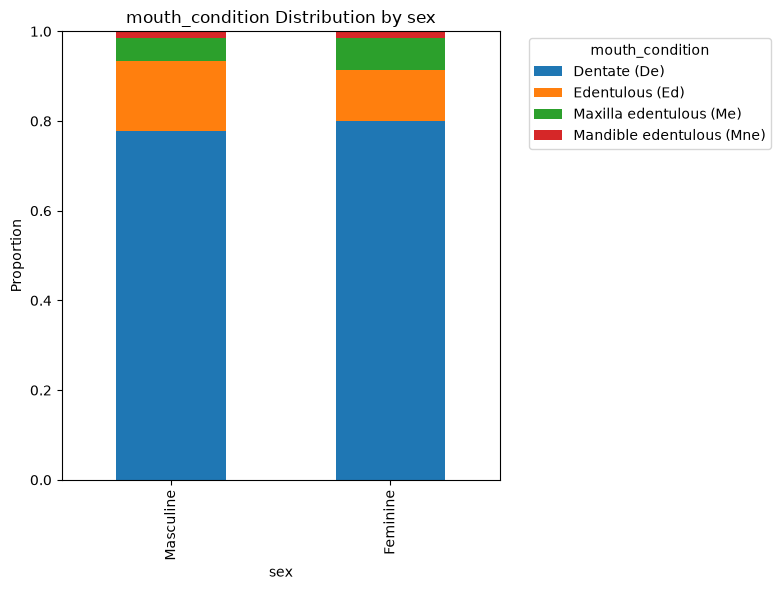

Feature 1,Feature 2,Cramér's V,Chi-square,p-value,N
sex,mouth_condition,0.043,4.727,0.193,924


In [7]:
display_categorical_correlation_analysis(scaled_df3);

## Correlações categóricas x numéricas


In [8]:
def _compute_eta_squared(
    data_frame,
    numerical_feature,
    categorical_feature,
):
    """Compute eta-squared for a numerical-categorical pair."""
    grand_mean = data_frame[numerical_feature].mean()

    between_group_sum_of_squares = 0

    for _, group in data_frame.groupby(
        categorical_feature,
        observed=True,
    ):
        group_mean = group[numerical_feature].mean()
        group_size = len(group)

        between_group_sum_of_squares += group_size * (group_mean - grand_mean) ** 2

    total_sum_of_squares = ((data_frame[numerical_feature] - grand_mean) ** 2).sum()

    if total_sum_of_squares == 0:
        return 0.0

    return between_group_sum_of_squares / total_sum_of_squares


def _compute_anova_statistics(
    data_frame,
    numerical_feature,
    categorical_feature,
):
    """Compute one-way ANOVA statistics."""
    groups = [
        group[numerical_feature].to_numpy()
        for _, group in data_frame.groupby(
            categorical_feature,
            observed=True,
        )
        if len(group) > 0
    ]

    statistic, p_value = stats.f_oneway(*groups)

    return statistic, p_value


def _build_numerical_categorical_association_table(
    data_frame,
    numerical_columns,
    categorical_columns,
):
    """Build the numerical-categorical association table."""
    results = []

    for numerical_feature in numerical_columns:
        for categorical_feature in categorical_columns:
            statistic, p_value = _compute_anova_statistics(
                data_frame,
                numerical_feature,
                categorical_feature,
            )

            results.append(
                {
                    "Numerical Feature": numerical_feature,
                    "Categorical Feature": categorical_feature,
                    "Eta-squared": _compute_eta_squared(
                        data_frame,
                        numerical_feature,
                        categorical_feature,
                    ),
                    "F-statistic": statistic,
                    "p-value": p_value,
                }
            )

    return (
        pd.DataFrame(results)
        .sort_values(
            "Eta-squared",
            ascending=False,
        )
        .reset_index(drop=True)
    )


def _display_numerical_categorical_association_table(
    associations,
    title,
):
    """Display numerical-categorical associations as an HTML table."""
    table = associations.copy()

    for column in [
        "Eta-squared",
        "F-statistic",
        "p-value",
    ]:
        table[column] = table[column].map(
            lambda value: f"{value:.3f}" if pd.notna(value) else "—"
        )

    display(table.style.hide(axis="index").set_caption(title))


def display_numerical_categorical_correlation_analysis(
    data_frame,
):
    """
    Analyze associations between numerical and categorical
    predictor features.
    """
    numerical_columns = df3_numerical_features

    categorical_columns = df3_categorical_features

    if not numerical_columns:
        raise ValueError("No numerical condition-count features were found.")

    if not categorical_columns:
        raise ValueError("No categorical predictor features were found.")

    associations = _build_numerical_categorical_association_table(
        data_frame,
        numerical_columns,
        categorical_columns,
    )

    _display_numerical_categorical_association_table(
        associations,
        "Numerical-Categorical Feature Associations",
    )

    return {
        "associations": associations,
    }

In [9]:
display_numerical_categorical_correlation_analysis(scaled_df3);

Numerical Feature,Categorical Feature,Eta-squared,F-statistic,p-value
amount_of_h,mouth_condition,0.319,143.929,0.000
amount_of_r,mouth_condition,0.281,119.847,0.000
amount_of_te,mouth_condition,0.082,27.250,0.000
amount_of_m3i,mouth_condition,0.037,11.929,0.000
amount_of_c,mouth_condition,0.029,9.315,0.000
amount_of_cpum,mouth_condition,0.027,8.352,0.000
amount_of_di,mouth_condition,0.017,5.168,0.002
amount_of_m3f,mouth_condition,0.016,4.968,0.002
amount_of_p,mouth_condition,0.012,3.757,0.011
amount_of_c,sex,0.010,9.742,0.002
